In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [5]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [6]:
df.sample(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1089,ham,Goodmorning today i am late for &lt;DECIMAL&g...,NaN,NaN,NaN
944,ham,I sent my scores to sophas and i had to do sec...,NaN,NaN,NaN
3246,ham,* You gonna ring this weekend or wot?,NaN,NaN,NaN


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [10]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [11]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)

In [12]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


In [14]:
df[df["v1"]=="spam"]["v2"][2]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [15]:
df[df["v1"]=="ham"]["v2"][4]

"Nah I don't think he goes to usf, he lives around here though"

In [16]:
df.rename(columns={"v1":"Target","v2":"Text"},inplace=True)

In [17]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='Target'>

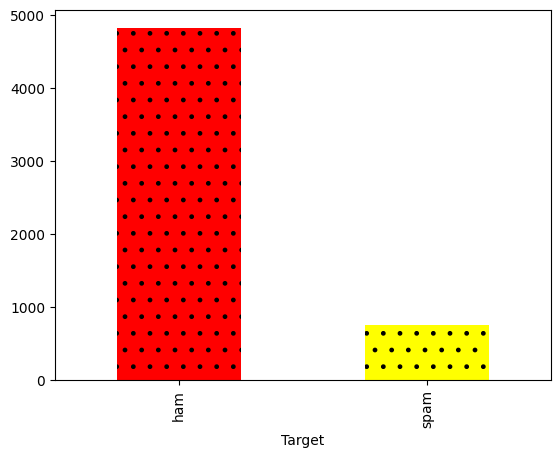

In [18]:
df["Target"].value_counts().plot(kind = "bar",color=["red","yellow"],hatch=".")

<Axes: ylabel='count'>

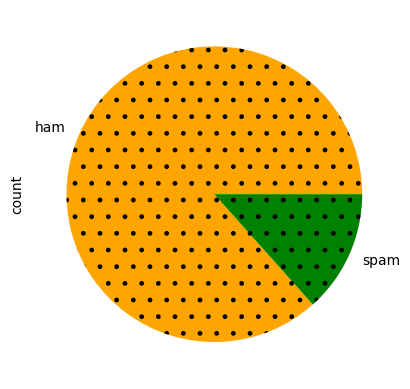

In [19]:
df["Target"].value_counts().plot(kind ="pie",colors = ["orange","green"], hatch = ".")

In [20]:
df.duplicated().sum()

np.int64(403)

In [21]:
df.drop_duplicates(keep ="first", inplace =True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.shape

(5169, 2)

In [24]:
! pip install nltk

In [25]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [26]:
df["num_chars"] = df["Text"].apply(len)

In [27]:
df.sample(3)

,Target,Text,num_chars
644,ham,Allo! We have braved the buses and taken on th...,127
422,ham,Siva is in hostel aha:-.,24
4173,ham,And pls pls drink plenty plenty water,37


In [28]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [29]:
df["num_words"] = df["Text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [30]:
df

,Target,Text,num_chars,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [33]:
df["num_sent"] = df["Target"].apply(lambda x:len(nltk.sent_tokenize(x)))


In [32]:
df

,Target,Text,num_chars,num_words,num_sent
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,1
1,ham,Ok lar... Joking wif u oni...,29,8,1
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,1
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [35]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Target2"] = encoder.fit_transform(df["Target"])

In [37]:
df = df[['Target','Target2','Text','num_chars','num_words','num_sent']]

In [38]:
df

,Target,Target2,Text,num_chars,num_words,num_sent
0,ham,0,"Go until jurong point, crazy.. Available only ...",111,24,1
1,ham,0,Ok lar... Joking wif u oni...,29,8,1
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1
3,ham,0,U dun say so early hor... U c already then say...,49,13,1
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,spam,1,This is the 2nd time we have tried 2 contact u...,161,35,1
5568,ham,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,0,"Pity, * was in mood for that. So...any other s...",57,15,1
5570,ham,0,The guy did some bitching but I acted like i'd...,125,27,1


In [39]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [42]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [43]:
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)
  text = y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)
  t=y[:]
  y.clear()
  for i in t:
    y.append(ps.stem(i))
  return " ".join(y)

In [44]:
transform_text("did you like my presentation on ml?")

'like present ml'

In [45]:
transform_text("i loved youtube lectures on ml, how about you?")

'love youtub lectur ml'

In [46]:
df["transformed_text"] = df["Text"].apply(transform_text)

/tmp/ipykernel_8664/3335711490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transformed_text"] = df["Text"].apply(transform_text)


In [47]:
df

,Target,Target2,Text,num_chars,num_words,num_sent,transformed_text
0,ham,0,"Go until jurong point, crazy.. Available only ...",111,24,1,go jurong point crazi avail bugi n great world...
1,ham,0,Ok lar... Joking wif u oni...,29,8,1,ok lar joke wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,1,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,ham,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...,...
5567,spam,1,This is the 2nd time we have tried 2 contact u...,161,35,1,2nd time tri 2 contact u pound prize 2 claim e...
5568,ham,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,ham,0,"Pity, * was in mood for that. So...any other s...",57,15,1,piti mood suggest
5570,ham,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [51]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

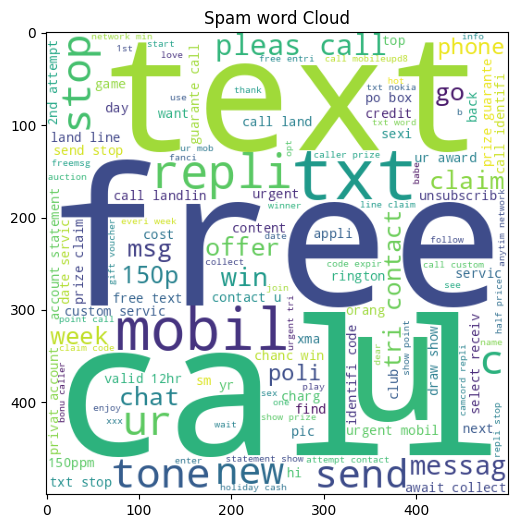

In [59]:
spam_word_cloud = wc.generate(df[df["Target2"]==1]["transformed_text"].str.cat(sep =" "))
plt.figure(figsize=(15,6))
plt.title("Spam word Cloud")
plt.imshow(spam_word_cloud);

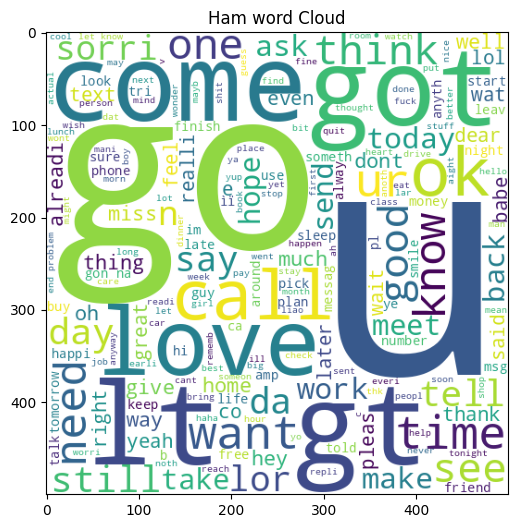

In [60]:
ham_word_cloud = wc.generate(df[df["Target2"]==0]["transformed_text"].str.cat(sep =" "))
plt.figure(figsize=(15,6))
plt.title("Ham word Cloud")
plt.imshow(ham_word_cloud)

# Model Building

In [62]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv = CountVectorizer()
tfidf = TfidfTransformer()

In [64]:
x_counts = cv.fit_transform(df["transformed_text"])
x = tfidf.fit_transform(x_counts).toarray()

In [65]:
y = df["Target2"].values

In [66]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2,random_state=42)
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [72]:
mnb = MultinomialNB()
mnb.fit(x_train,y_train)
y_pred = mnb.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ",round(accuracy,2))

Accuracy :  0.96


In [73]:
def predict_spam_probability(message):

    # Preprocess
    transformed = transform_text(message)

    # Vectorize
    vector_input = cv.transform([transformed])

    # TF-IDF
    tfidf_input = tfidf.transform(vector_input)

    # Get probabilities
    prob = mnb.predict_proba(tfidf_input)[0]

    return {
        "Ham Probability": round(prob[0], 2),
        "Spam Probability": round(prob[1], 2)
    }

In [74]:
predict_spam_probability("you win a lottery worth of 1 crore.")

{'Ham Probability': np.float64(0.55), 'Spam Probability': np.float64(0.45)}

In [75]:
predict_spam_probability("You are under digital arrest.")

{'Ham Probability': np.float64(0.75), 'Spam Probability': np.float64(0.25)}